In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import copy
import json

import numpy as np
import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AlbertForSequenceClassification,
    AlbertTokenizer,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import f1_score

from tqdm.auto import tqdm

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
LABEL2ID = {"e": 0, "n": 1, "c": 2}
BASE     = "drive/MyDrive/anli/"

def load_jsonl(filepath):
    with open(filepath) as f:
        return [json.loads(l) for l in open(filepath) if l.strip()]

class ANLIDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data[idx]
        enc = tokenizer(row["context"], row["hypothesis"],
                        max_length=128, truncation=True,
                        padding="max_length", return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(LABEL2ID[row["label"]], dtype=torch.long)
        }

r1_data = load_jsonl(BASE + "R1/" + "train.jsonl")
r2_data = load_jsonl(BASE + "R2/" + "train.jsonl")
r3_data = load_jsonl(BASE + "R3/" + "train.jsonl")
r1_dev  = load_jsonl(BASE + "R1/" + "dev.jsonl")
r2_dev  = load_jsonl(BASE + "R2/" + "dev.jsonl")
r3_dev  = load_jsonl(BASE + "R3/" + "dev.jsonl")

print("R1:", len(r1_data), "| R2:", len(r2_data), "| R3:", len(r3_data))

R1: 16946 | R2: 45460 | R3: 100459


In [4]:
def evaluate(model, data, device):
    model.eval()

    loader = DataLoader(
        ANLIDataset(data),
        batch_size=32,
        shuffle=False
    )

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            preds = outputs.logits.argmax(dim=-1)

            total_loss += outputs.loss.item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))

    f1 = f1_score(
        all_labels,
        all_preds,
        average=None,
        labels=[0, 1, 2]
    )

    avg_loss = total_loss / len(loader)

    return avg_loss, acc, f1

In [8]:
model_path = "/content/drive/MyDrive/albert_curriculum/curriculum_model"

from transformers import AlbertForSequenceClassification, AlbertTokenizer

tokenizer = AlbertTokenizer.from_pretrained(model_path)
Final_Albert_model = AlbertForSequenceClassification.from_pretrained(model_path).to(device)

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

In [11]:
ID2LABEL = {0: "entailment", 1: "neutral", 2: "contradiction"}

def high_confidence_wrong(model, data, device, threshold=0.90):
    model.eval()
    loader = DataLoader(ANLIDataset(data), batch_size=32, shuffle=False)
    cases  = []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"]
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            probs          = F.softmax(outputs.logits, dim=-1).cpu()
            confs, preds   = probs.max(dim=-1)
            for i in range(len(labels)):
                if preds[i] != labels[i] and confs[i] >= threshold:
                    cases.append({
                        "predicted":  ID2LABEL[preds[i].item()],
                        "true_label": ID2LABEL[labels[i].item()],
                        "confidence": round(confs[i].item(), 4),
                    })
    return cases

for split_name, test_data in [
    ("R1", r1_test),
    ("R2", r2_test),
    ("R3", r3_test),
]:
    cases = high_confidence_wrong(Final_Albert_model, test_data, device)
    print(f"{split_name}: {len(cases)} high-confidence mistakes out of {len(test_data)} examples")

R1: 49 high-confidence mistakes out of 1000 examples
R2: 79 high-confidence mistakes out of 1000 examples
R3: 89 high-confidence mistakes out of 1200 examples


In [12]:
ID2LABEL = {0: "entailment", 1: "neutral", 2: "contradiction"}

def high_confidence_wrong(model, data, device, threshold=0.80):
    model.eval()
    loader = DataLoader(ANLIDataset(data), batch_size=32, shuffle=False)
    cases  = []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"]
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            probs          = F.softmax(outputs.logits, dim=-1).cpu()
            confs, preds   = probs.max(dim=-1)
            for i in range(len(labels)):
                if preds[i] != labels[i] and confs[i] >= threshold:
                    cases.append({
                        "predicted":  ID2LABEL[preds[i].item()],
                        "true_label": ID2LABEL[labels[i].item()],
                        "confidence": round(confs[i].item(), 4),
                    })
    return cases

for split_name, test_data in [
    ("R1", r1_test),
    ("R2", r2_test),
    ("R3", r3_test),
]:
    cases = high_confidence_wrong(Final_Albert_model, test_data, device)
    print(f"{split_name}: {len(cases)} high-confidence mistakes out of {len(test_data)} examples")

R1: 121 high-confidence mistakes out of 1000 examples
R2: 186 high-confidence mistakes out of 1000 examples
R3: 207 high-confidence mistakes out of 1200 examples


In [13]:
ID2LABEL = {0: "entailment", 1: "neutral", 2: "contradiction"}

def high_confidence_wrong(model, data, device, threshold=0.7):
    model.eval()
    loader = DataLoader(ANLIDataset(data), batch_size=32, shuffle=False)
    cases  = []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"]
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            probs          = F.softmax(outputs.logits, dim=-1).cpu()
            confs, preds   = probs.max(dim=-1)
            for i in range(len(labels)):
                if preds[i] != labels[i] and confs[i] >= threshold:
                    cases.append({
                        "predicted":  ID2LABEL[preds[i].item()],
                        "true_label": ID2LABEL[labels[i].item()],
                        "confidence": round(confs[i].item(), 4),
                    })
    return cases

for split_name, test_data in [
    ("R1", r1_test),
    ("R2", r2_test),
    ("R3", r3_test),
]:
    cases = high_confidence_wrong(Final_Albert_model, test_data, device)
    print(f"{split_name}: {len(cases)} high-confidence mistakes out of {len(test_data)} examples")

R1: 208 high-confidence mistakes out of 1000 examples
R2: 299 high-confidence mistakes out of 1000 examples
R3: 308 high-confidence mistakes out of 1200 examples


In [14]:
ID2LABEL = {0: "entailment", 1: "neutral", 2: "contradiction"}

def high_confidence_wrong(model, data, device, threshold=0.6):
    model.eval()
    loader = DataLoader(ANLIDataset(data), batch_size=32, shuffle=False)
    cases  = []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"]
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            probs          = F.softmax(outputs.logits, dim=-1).cpu()
            confs, preds   = probs.max(dim=-1)
            for i in range(len(labels)):
                if preds[i] != labels[i] and confs[i] >= threshold:
                    cases.append({
                        "predicted":  ID2LABEL[preds[i].item()],
                        "true_label": ID2LABEL[labels[i].item()],
                        "confidence": round(confs[i].item(), 4),
                    })
    return cases

for split_name, test_data in [
    ("R1", r1_test),
    ("R2", r2_test),
    ("R3", r3_test),
]:
    cases = high_confidence_wrong(Final_Albert_model, test_data, device)
    print(f"{split_name}: {len(cases)} high-confidence mistakes out of {len(test_data)} examples")

R1: 282 high-confidence mistakes out of 1000 examples
R2: 392 high-confidence mistakes out of 1000 examples
R3: 428 high-confidence mistakes out of 1200 examples


In [15]:
model_path = "/content/drive/MyDrive/albert_r2_model"

from transformers import AlbertForSequenceClassification, AlbertTokenizer

tokenizer = AlbertTokenizer.from_pretrained(model_path)
Albert_R2_model = AlbertForSequenceClassification.from_pretrained(model_path).to(device)

Loading weights:   0%|          | 0/27 [00:01<?, ?it/s]

In [17]:
model_path = "/content/drive/MyDrive/albert_r3_model"

from transformers import AlbertForSequenceClassification, AlbertTokenizer

tokenizer = AlbertTokenizer.from_pretrained(model_path)
Albert_R3_model = AlbertForSequenceClassification.from_pretrained(model_path).to(device)

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

In [19]:
model_path = "/content/drive/MyDrive/albert_curriculum/best_R1"

from transformers import AlbertForSequenceClassification, AlbertTokenizer

tokenizer = AlbertTokenizer.from_pretrained(model_path)
Albert_R1_model = AlbertForSequenceClassification.from_pretrained(model_path).to(device)

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

In [22]:
model_path = "/content/drive/MyDrive/albert_mixed_training"

from transformers import AlbertForSequenceClassification, AlbertTokenizer

tokenizer = AlbertTokenizer.from_pretrained(model_path)
Albert_MT_model = AlbertForSequenceClassification.from_pretrained(model_path).to(device)

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

In [30]:
model_path = "/content/drive/MyDrive/albert_curriculum/best_R2"

from transformers import AlbertForSequenceClassification, AlbertTokenizer

tokenizer = AlbertTokenizer.from_pretrained(model_path)
Albert_R12_model = AlbertForSequenceClassification.from_pretrained(model_path).to(device)

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

In [31]:
model_path = "/content/drive/MyDrive/albert_curriculum/best_R3"

from transformers import AlbertForSequenceClassification, AlbertTokenizer

tokenizer = AlbertTokenizer.from_pretrained(model_path)
Albert_R123_model = AlbertForSequenceClassification.from_pretrained(model_path).to(device)

Loading weights:   0%|          | 0/27 [00:00<?, ?it/s]

In [20]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)

for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Albert_R1_model, test_data, device)
    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.1584        0.4330      0.4236        0.5328        0.3065
R2 test   1.3596        0.3460      0.3646        0.4204        0.1996
R3 test   1.4439        0.3367      0.2433        0.4763        0.1301


In [16]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)

for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Albert_R2_model, test_data, device)
    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.1820        0.4950      0.5113        0.6163        0.2746
R2 test   1.4041        0.4010      0.4720        0.4512        0.1755
R3 test   1.4442        0.3767      0.4208        0.4599        0.1301


In [18]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)

for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Albert_R3_model, test_data, device)
    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.1603        0.5060      0.5399        0.5405        0.4113
R2 test   1.3459        0.4190      0.4879        0.4235        0.3037
R3 test   1.3198        0.4200      0.4714        0.4530        0.3088


In [9]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)


for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Final_Albert_model, test_data, device)
    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.0458        0.5550      0.5725        0.6119        0.4618
R2 test   1.3227        0.4360      0.4901        0.4601        0.3279
R3 test   1.2879        0.4617      0.5011        0.4971        0.3671


In [23]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)


for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Albert_MT_model, test_data, device)
    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.0861        0.5580      0.5674        0.6047        0.4940
R2 test   1.3830        0.4390      0.4821        0.4587        0.3592
R3 test   1.3542        0.4475      0.4778        0.4686        0.3891


In [32]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)


for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Albert_R1_model, test_data, device)
    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.1584        0.4330      0.4236        0.5328        0.3065
R2 test   1.3596        0.3460      0.3646        0.4204        0.1996
R3 test   1.4439        0.3367      0.2433        0.4763        0.1301


In [33]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)


for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Albert_R12_model, test_data, device)
    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.0855        0.5160      0.5253        0.5737        0.4341
R2 test   1.3725        0.4160      0.4794        0.4328        0.2896
R3 test   1.4109        0.4008      0.4508        0.4626        0.2023


In [34]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)


for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Albert_R123_model, test_data, device)
    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.0458        0.5550      0.5725        0.6119        0.4618
R2 test   1.3227        0.4360      0.4901        0.4601        0.3279
R3 test   1.2879        0.4617      0.5011        0.4971        0.3671


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [25]:
def plot_confusion_matrix(model, data, device, title):
    model.eval()

    loader = DataLoader(ANLIDataset(data), batch_size=32, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=[0, 1, 2]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Entailment", "Neutral", "Contradiction"]
    )

    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(title)
    plt.show()


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.0861        0.5580      0.5674        0.6047        0.4940


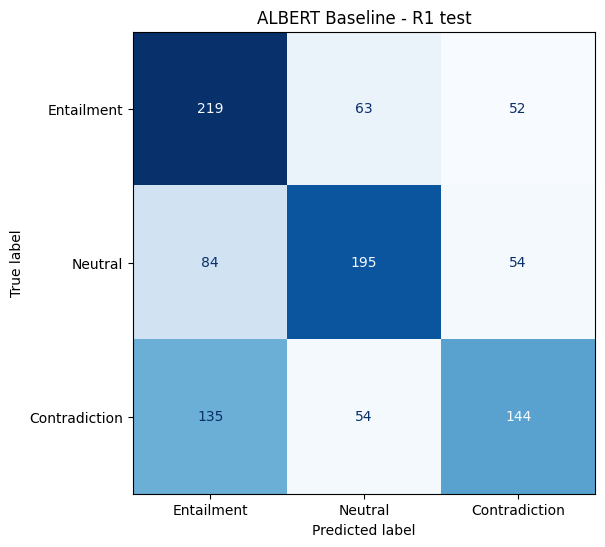

R2 test   1.3830        0.4390      0.4821        0.4587        0.3592


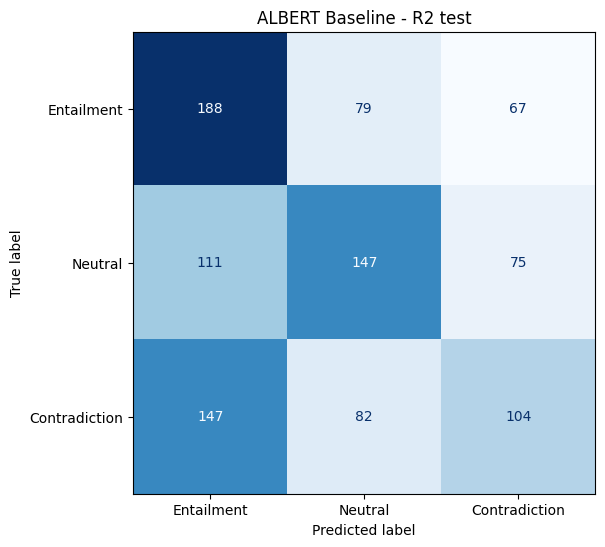

R3 test   1.3542        0.4475      0.4778        0.4686        0.3891


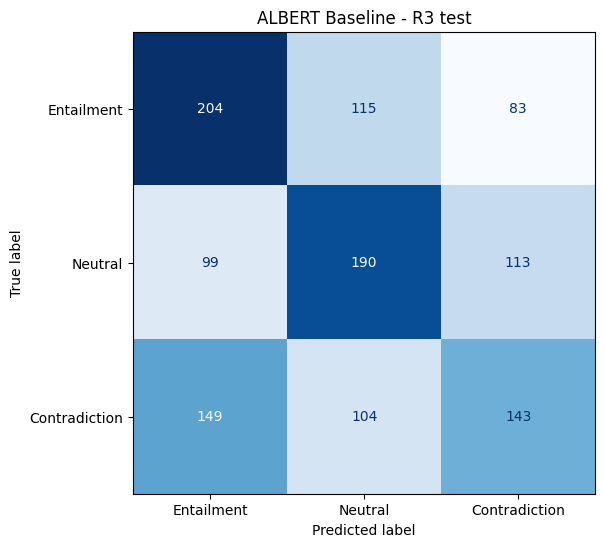

In [26]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)

for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Albert_MT_model, test_data, device)

    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")

    plot_confusion_matrix(
        Albert_MT_model,
        test_data,
        device,
        f"ALBERT Baseline - {split_name}"
    )


Split     Test Loss     Accuracy    F1 Entail     F1 Neutral    F1 Contra
------------------------------------------------------------------------
R1 test   1.0458        0.5550      0.5725        0.6119        0.4618


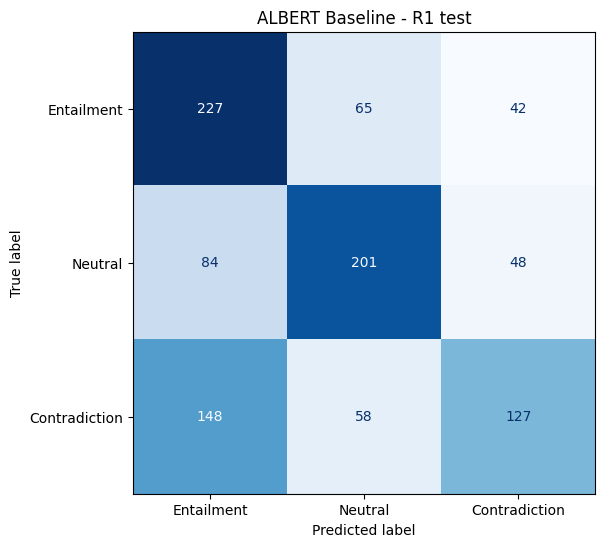

R2 test   1.3227        0.4360      0.4901        0.4601        0.3279


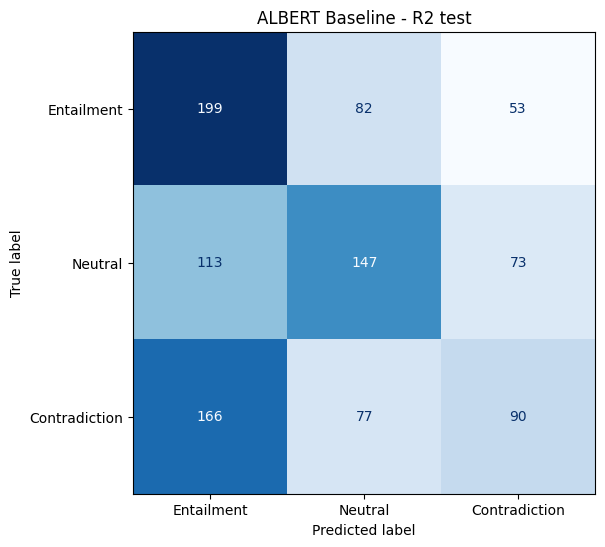

R3 test   1.2879        0.4617      0.5011        0.4971        0.3671


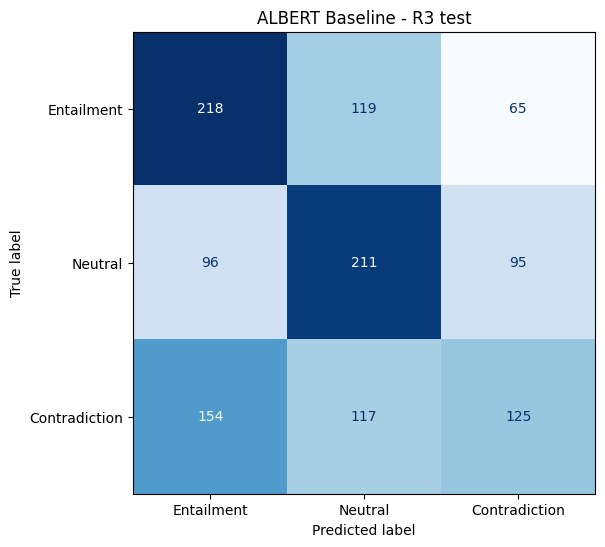

In [28]:
r1_test = load_jsonl(BASE + "R1/" + "test.jsonl")
r2_test = load_jsonl(BASE + "R2/" + "test.jsonl")
r3_test = load_jsonl(BASE + "R3/" + "test.jsonl")

print(f"\n{'Split':<10}{'Test Loss':<14}{'Accuracy':<12}{'F1 Entail':<14}{'F1 Neutral':<14}{'F1 Contra'}")
print("-" * 72)

for split_name, test_data in [
    ("R1 test", r1_test),
    ("R2 test", r2_test),
    ("R3 test", r3_test),
]:
    loss, acc, f1 = evaluate(Final_Albert_model, test_data, device)

    print(f"{split_name:<10}{loss:<14.4f}{acc:<12.4f}{f1[0]:<14.4f}{f1[1]:<14.4f}{f1[2]:.4f}")

    plot_confusion_matrix(
        Final_Albert_model,
        test_data,
        device,
        f"ALBERT Baseline - {split_name}"
    )